<a href="https://colab.research.google.com/github/Supraja-Kurapati/Comptia_DataAI_Projects/blob/main/CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE= 224
BATCH_SIZE= 32


In [ ]:
import os

# Set Kaggle credentials directly via environment variables
# Replace the placeholders with the actual values from your downloaded kaggle.json file
os.environ['KAGGLE_USERNAME'] = "Kurapati Venkata Sai Supraja"
os.environ['KAGGLE_KEY'] = "KGAT_1ac3d754e150d32e1cccb47503eb457d"

# Install the Kaggle CLI library
!pip install -q kaggle

In [ ]:
# Download the dataset files
!kaggle datasets download -d samuelcortinhas/muffin-vs-chihuahua-image-classification

# Unzip the downloaded dataset into a folder
!unzip -q muffin-vs-chihuahua-image-classification.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
License(s): CC0-1.0
100% 474M/474M [00:19<00:00, 25.8MB/s]



In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    './dataset/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './dataset/test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 4733 files belonging to 2 classes.
Found 1184 files belonging to 2 classes.


In [ ]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Build CNN Architecture
model = keras.Sequential([
    # Input Rescaling ([0, 255] -> [0, 1])
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier
    layers.GlobalAveragePooling2D(),  # Keeps parameter count low
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary output
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4. Train Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.6527 - loss: 0.6115 - val_accuracy: 0.7956 - val_loss: 0.4625
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.8014 - loss: 0.4550 - val_accuracy: 0.8150 - val_loss: 0.4077
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.8363 - loss: 0.3954 - val_accuracy: 0.8623 - val_loss: 0.3289
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.8462 - loss: 0.3642 - val_accuracy: 0.8784 - val_loss: 0.3067
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.8593 - loss: 0.3483 - val_accuracy: 0.8894 - val_loss: 0.2847
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.8692 - loss: 0.3277 - val_accuracy: 0.8978 - val_loss: 0.2719
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.8730 - loss: 0.3183 - val_accuracy: 0.8986 - val_loss: 0.2721
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.8785 - loss: 0.2998 - val_accu

In [ ]:
model.save('/content/drive/MyDrive/ChihhuaVsMuffin.h5')

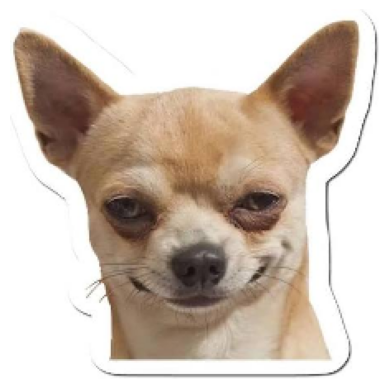

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Chihuahua (95.72%)


In [ ]:
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Image URL and local save path
test_image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRS_WhnNyArV8JIJYdE0MuZNPHCbrMYqnRCoc3mk2bG6Q&s=10"
local_image_path = "test_img.jpg"

# 2. Download the image locally
urllib.request.urlretrieve(test_image_url, local_image_path)

# 3. Load and display the image
img = image.load_img(local_image_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')
plt.show()

# 4. Preprocess image for prediction
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Shape becomes (1, 224, 224, 3)

# 5. Predict
prediction = model.predict(img_array)[0][0]

# TensorFlow image_dataset_from_directory assigns labels alphabetically:
# 0 -> chihuahua, 1 -> muffin (or check train_ds.class_names)
if prediction >= 0.6:
    print(f"Prediction: Muffin ({prediction:.2%})")
else:
    print(f"Prediction: Chihuahua ({1 - prediction:.2%})")